# Лабораторная работа 6: MLP (Mushroom Dataset)

**Задание:**
- Использовать датасет `mushroom`.
- Реализовать многослойный персептрон с **2 скрытыми слоями**.
- Функция активации: **sigmoid**.
- Обучение: **градиентный спуск без оптимизаторов**.
- Посчитать `accuracy`, `precision`, `recall`, `F1`.
- Построить ROC-кривую.

Ниже реализован бинарный классификатор (1 выходной нейрон):
- класс `1` — poisonous,
- класс `0` — edible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

## 1) Загрузка и подготовка данных

В наборе `mushroom/agaricus-lepiota.data`:
- первый столбец — класс (`e`/`p`),
- остальные 22 признака категориальные.

Подготовка:
- one-hot кодирование признаков,
- перевод метки в бинарный вид (`p -> 1`, `e -> 0`),
- стратифицированное разделение на train/test (80/20),
- стандартизация по train-части.

In [2]:
data_path = Path("mushroom") / "agaricus-lepiota.data"

if not data_path.exists():
    raise FileNotFoundError(f"Не найден файл датасета: {data_path}")

raw = pd.read_csv(data_path, header=None)

y = (raw.iloc[:, 0] == "p").astype(np.float64).to_numpy().reshape(-1, 1)
X_cat = raw.iloc[:, 1:].copy()

# One-hot кодирование категориальных признаков
X_encoded = pd.get_dummies(X_cat, columns=X_cat.columns, drop_first=False)
X = X_encoded.to_numpy(dtype=np.float64)

# Стратифицированное разделение: сохраняем доли классов в train/test
class0_idx = np.where(y.reshape(-1) == 0)[0]
class1_idx = np.where(y.reshape(-1) == 1)[0]

rng = np.random.default_rng(42)
rng.shuffle(class0_idx)
rng.shuffle(class1_idx)

split0 = int(0.8 * len(class0_idx))
split1 = int(0.8 * len(class1_idx))

train_idx = np.concatenate([class0_idx[:split0], class1_idx[:split1]])
test_idx = np.concatenate([class0_idx[split0:], class1_idx[split1:]])

rng.shuffle(train_idx)
rng.shuffle(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Стандартизация (на one-hot обычно не обязательна, но делает обучение стабильнее)
mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True)
std = np.where(std < 1e-12, 1.0, std)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Доля класса 1 (poisonous) в train:", y_train.mean().round(4))
print("Доля класса 1 (poisonous) в test:", y_test.mean().round(4))

X_train: (6498, 117) X_test: (1626, 117)
Доля класса 1 (poisonous) в train: 0.482
Доля класса 1 (poisonous) в test: 0.4822


## 2) Реализация MLP (2 скрытых слоя, sigmoid, GD)

Архитектура:
- вход: `n_features`,
- скрытый слой 1: 32 нейрона + sigmoid,
- скрытый слой 2: 16 нейрона + sigmoid,
- выход: 1 нейрон + sigmoid.

Почему 1 выходной нейрон:
- задача бинарная (`edible` / `poisonous`), поэтому достаточно одного выхода,
- значение выхода интерпретируется как вероятность класса `poisonous`,
- порог 0.5 дает итоговый класс.

Функция потерь: бинарная кросс-энтропия.
Обучение: полный batch gradient descent.

In [3]:
def sigmoid(x):
    x = np.clip(x, -30, 30)
    return 1.0 / (1.0 + np.exp(-x))


def bce_loss(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


class MLPBinaryClassifier:
    def __init__(self, n_inputs, n_hidden1=32, n_hidden2=16, lr=0.1, seed=42):
        rng = np.random.default_rng(seed)

        self.W1 = rng.normal(0.0, 0.1, size=(n_inputs, n_hidden1))
        self.b1 = np.zeros((1, n_hidden1))

        self.W2 = rng.normal(0.0, 0.1, size=(n_hidden1, n_hidden2))
        self.b2 = np.zeros((1, n_hidden2))

        self.W3 = rng.normal(0.0, 0.1, size=(n_hidden2, 1))
        self.b3 = np.zeros((1, 1))

        self.lr = lr
        self.history = []

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = sigmoid(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)

        z3 = a2 @ self.W3 + self.b3
        y_prob = sigmoid(z3)

        cache = (X, z1, a1, z2, a2, z3, y_prob)
        return y_prob, cache

    def backward(self, y_true, cache):
        X, _z1, a1, _z2, a2, _z3, y_prob = cache
        m = X.shape[0]

        # Для sigmoid + BCE: dL/dz3 = (y_prob - y_true)
        dz3 = (y_prob - y_true)
        dW3 = (a2.T @ dz3) / m
        db3 = dz3.mean(axis=0, keepdims=True)

        da2 = dz3 @ self.W3.T
        dz2 = da2 * a2 * (1 - a2)
        dW2 = (a1.T @ dz2) / m
        db2 = dz2.mean(axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * a1 * (1 - a1)
        dW1 = (X.T @ dz1) / m
        db1 = dz1.mean(axis=0, keepdims=True)

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=1500, verbose_every=100):
        self.history = []

        for epoch in range(1, epochs + 1):
            y_prob, cache = self.forward(X)
            loss = bce_loss(y, y_prob)
            self.backward(y, cache)
            self.history.append(loss)

            if epoch % verbose_every == 0 or epoch == 1:
                print(f"Epoch {epoch:4d} | loss = {loss:.6f}")

        return self

    def predict_proba(self, X):
        y_prob, _ = self.forward(X)
        return y_prob

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(np.float64)


mlp = MLPBinaryClassifier(
    n_inputs=X_train.shape[1],
    n_hidden1=32,
    n_hidden2=16,
    lr=0.2,
    seed=42,
)

mlp.fit(X_train, y_train, epochs=1200, verbose_every=150)

Epoch    1 | loss = 0.691293
Epoch  150 | loss = 0.395638
Epoch  300 | loss = 0.040027
Epoch  450 | loss = 0.014423
Epoch  600 | loss = 0.008453
Epoch  750 | loss = 0.005996
Epoch  900 | loss = 0.004693
Epoch 1050 | loss = 0.003895
Epoch 1200 | loss = 0.003358


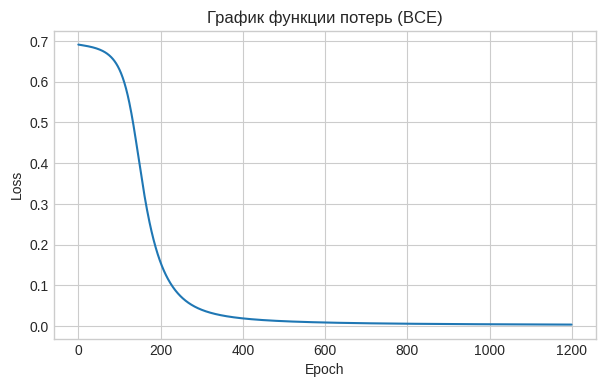

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(mlp.history)
plt.title("График функции потерь (BCE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 3) Оценка качества: accuracy, precision, recall, F1

In [5]:
def classification_metrics(y_true, y_pred):
    y_true = y_true.astype(np.float64).reshape(-1, 1)
    y_pred = y_pred.astype(np.float64).reshape(-1, 1)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    eps = 1e-12
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


y_test_prob = mlp.predict_proba(X_test)
y_test_pred = (y_test_prob >= 0.5).astype(np.float64)

metrics = classification_metrics(y_test, y_test_pred)

print("Метрики на тесте:")
print(f"accuracy : {metrics['accuracy']:.4f}")
print(f"precision: {metrics['precision']:.4f}")
print(f"recall   : {metrics['recall']:.4f}")
print(f"f1       : {metrics['f1']:.4f}")
print()
print(f"TP={metrics['tp']}  FP={metrics['fp']}  TN={metrics['tn']}  FN={metrics['fn']}")

Метрики на тесте:
accuracy : 0.9988
precision: 1.0000
recall   : 0.9974
f1       : 0.9987

TP=782  FP=0  TN=842  FN=2


## 4) ROC-кривая и ROC-AUC

ROC строится вручную: для набора порогов считаем `TPR` и `FPR`.

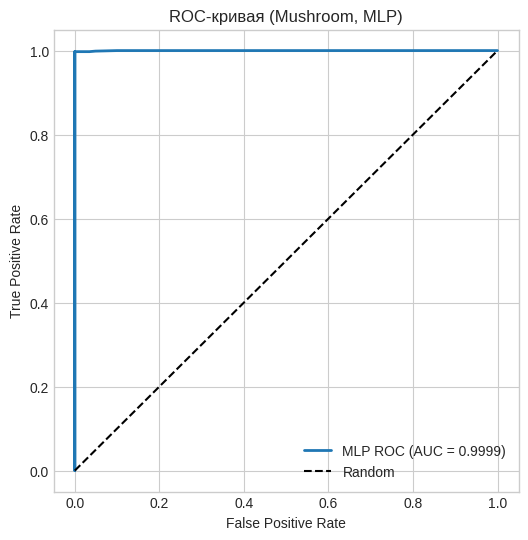

ROC-AUC: 0.9999


In [6]:
def roc_curve_manual(y_true, y_prob, n_thresholds=400):
    y_true = y_true.reshape(-1)
    y_prob = y_prob.reshape(-1)

    thresholds = np.linspace(0.0, 1.0, n_thresholds)
    tpr_list = []
    fpr_list = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.float64)

        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        tpr = tp / (tp + fn + 1e-12)
        fpr = fp / (fp + tn + 1e-12)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    fpr = np.array(fpr_list)
    tpr = np.array(tpr_list)

    # Для интегрирования AUC отсортируем точки по FPR
    order = np.argsort(fpr)
    fpr_sorted = fpr[order]
    tpr_sorted = tpr[order]

    roc_auc = np.trapezoid(tpr_sorted, fpr_sorted)
    return fpr_sorted, tpr_sorted, roc_auc


fpr, tpr, roc_auc = roc_curve_manual(y_test, y_test_prob, n_thresholds=500)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"MLP ROC (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (Mushroom, MLP)")
plt.legend(loc="lower right")
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")